2802460905 video:https://youtu.be/gN9eduww5P0

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

from sklearn.model_selection import (train_test_split, cross_val_score, StratifiedKFold,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print("✅ Libraries loaded.")

✅ Libraries loaded.


In [2]:
df = pd.read_csv('data/data_A_md.csv')

print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
print()
display(df.head())
display(df.dtypes)

Shape  : (25000, 29)
Columns: ['Unnamed: 0', 'ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']



,Unnamed: 0,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0,0xa658,CUS_0x936d,March,Alistair Barrs,8466,703-48-3482,_______,100433.58,8074.465000,...,Good,1023.93,33.471395,20 Years and 5 Months,No,100.163466,758.0704866746678,Low_spent_Medium_value_payments,229.21254743638283,Standard
1,1,0x6739,CUS_0x9a29,August,Phila,25,339-28-0072,Developer,33119.82,3024.985000,...,Bad,2545.0,33.810567,14 Years and 8 Months,Yes,111.422702,NaN,Low_spent_Small_value_payments,370.6074980582689,Poor
2,2,0xdcf5,CUS_0x12a9,April,Driverb,44,583-20-9758,_______,44822.21,3555.184167,...,Good,730.64,31.145739,23 Years and 10 Months,NM,135.044286,256.4742969677053,Low_spent_Medium_value_payments,243.99983412342044,Standard
3,3,0x14453,CUS_0x3bad,June,Prasadc,29,510-25-2095,Musician,142081.48,11771.123333,...,Standard,932.32,28.409526,27 Years and 0 Months,No,180.616478,423.96126196668365,Low_spent_Small_value_payments,862.534593039876,Standard
4,4,0x1198e,CUS_0xa3e1,January,Poornimai,45,943-92-4350,Scientist,19267.27_,1374.605833,...,Bad,3777.55,28.373426,10 Years and 3 Months,Yes,78.954825,133.56850235207634,Low_spent_Small_value_payments,214.93725572483646,Poor


Unnamed: 0                    int64
ID                           object
Customer_ID                  object
Month                        object
Name                         object
Age                          object
SSN                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance             

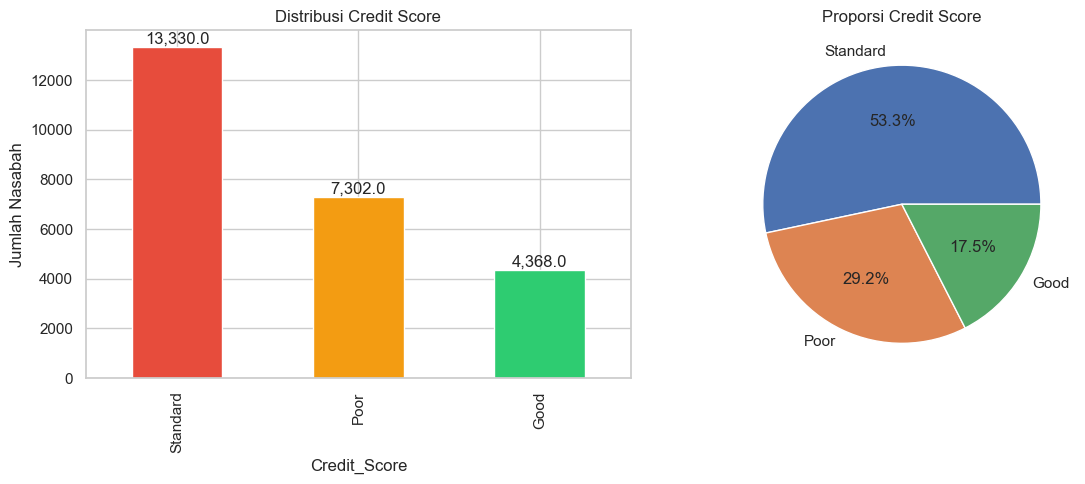

Kelas Target:
 Credit_Score
Standard    13330
Poor         7302
Good         4368
Name: count, dtype: int64

Rasio Imbalance: 3.05:1

 Missing Values (%) 
 Monthly_Inhand_Salary      14.33
Type_of_Loan               11.31
Name                       10.24
Credit_History_Age          9.00
Num_of_Delayed_Payment      6.93
Amount_invested_monthly     4.66
Num_Credit_Inquiries        2.02
Monthly_Balance             1.16
dtype: float64


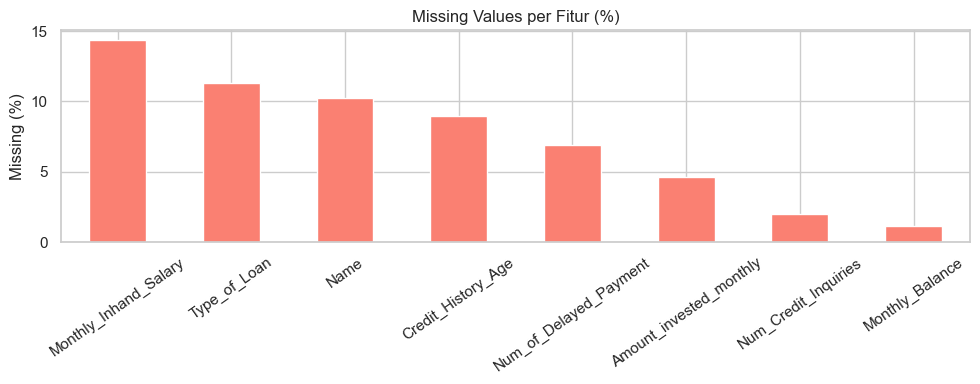

In [3]:
# ── Target Distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df['Credit_Score'].value_counts()
colors = ['#e74c3c', '#f39c12', '#2ecc71']

counts.plot(kind='bar', ax=axes[0], color=colors, title='Distribusi Credit Score', ylabel='Jumlah Nasabah')
axes[0].bar_label(axes[0].containers[0], fmt='{:,}')  # <-- Perbaikan di baris ini

counts.plot(kind='pie', ax=axes[1], color=colors, autopct='%1.1f%%', title='Proporsi Credit Score', ylabel='')

plt.tight_layout()
plt.show()

print("Kelas Target:\n", counts)
print(f"\nRasio Imbalance: {counts.max()/counts.min():.2f}:1")

#Missing Values
miss_pct = (df.isnull().sum() / len(df) * 100).round(2)
miss_pct = miss_pct[miss_pct > 0].sort_values(ascending=False)

print("\n Missing Values (%) \n", miss_pct)

miss_pct.plot(kind='bar', figsize=(10, 4), color='salmon', title='Missing Values per Fitur (%)', rot=35)
plt.ylabel('Missing (%)')
plt.tight_layout()
plt.show()

In [4]:
"""
╔══════════════════════════════════════════════════════════════════╗
║            i. FITUR YANG DIGUNAKAN                              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DIBUANG (tidak relevan / identifier):                           ║
║  ─ Unnamed: 0  → indeks duplikat                                ║
║  ─ ID          → pengenal unik, tidak informatif                ║
║  ─ Customer_ID → pengenal unik, tidak informatif                ║
║  ─ Name        → data PII, tidak prediktif                      ║
║  ─ SSN         → data PII sensitif                              ║
║  ─ Type_of_Loan→ teks bebas multi-label, terlalu kompleks       ║
║                                                                  ║
║  FITUR YANG DIPAKAI (22 fitur):                                 ║
║  ┌─ Demografis ──────────────────────────────────────────┐      ║
║  │  Age, Occupation, Month                               │      ║
║  └───────────────────────────────────────────────────────┘      ║
║  ┌─ Keuangan ────────────────────────────────────────────┐      ║
║  │  Annual_Income, Monthly_Inhand_Salary                 │      ║
║  │  Total_EMI_per_month, Amount_invested_monthly         │      ║
║  │  Monthly_Balance                                      │      ║
║  └───────────────────────────────────────────────────────┘      ║
║  ┌─ Perilaku Kredit ─────────────────────────────────────┐      ║
║  │  Num_Bank_Accounts, Num_Credit_Card, Num_of_Loan      │      ║
║  │  Interest_Rate, Delay_from_due_date                   │      ║
║  │  Num_of_Delayed_Payment, Changed_Credit_Limit         │      ║
║  │  Num_Credit_Inquiries, Credit_Mix                     │      ║
║  │  Outstanding_Debt, Credit_Utilization_Ratio           │      ║
║  │  Credit_History_Age (dikonversi ke bulan)             │      ║
║  │  Payment_of_Min_Amount, Payment_Behaviour             │      ║
║  └───────────────────────────────────────────────────────┘      ║
╚══════════════════════════════════════════════════════════════════╝
"""
print("Fitur yang akan digunakan: 22 fitur prediktif")

Fitur yang akan digunakan: 22 fitur prediktif


In [5]:
"""
║            ii. PRE-PROCESSING YANG DILAKUKAN                    ║
╠═════════════════════════════════════════════════════════════════╣
║  1. Hapus kolom tidak relevan                                   ║
║  2. Bersihkan nilai noise (trailing '_', placeholder, outlier)  ║
║  3. Feature engineering (Credit_History_Age → bulan)            ║
║  4. Imputasi missing values                                     ║
║  5. Encoding fitur kategorikal                                  ║
║  6. Standarisasi fitur numerik                                  ║
"""
df_clean = df.copy()

# ── 1. Hapus kolom tidak relevan ────────────────────────────────
DROP_COLS = ['Unnamed: 0', 'ID', 'Customer_ID', 'Name', 'SSN', 'Type_of_Loan','Month']
df_clean.drop(columns=DROP_COLS, inplace=True)
print(f"Shape setelah drop kolom: {df_clean.shape}")

# ── 2. Bersihkan noise ───────────────────────────────────────────

# Age: hapus trailing underscore, outlier > 100 atau < 18 → NaN
df_clean['Age'] = (df_clean['Age'].astype(str)
                                  .str.replace('_', '', regex=False)
                                  .str.strip())
df_clean['Age'] = pd.to_numeric(df_clean['Age'], errors='coerce')
df_clean.loc[(df_clean['Age'] > 100) | (df_clean['Age'] < 18), 'Age'] = np.nan
print(f"Age NaN setelah cleaning  : {df_clean['Age'].isna().sum()}")

# Annual_Income: hapus trailing '_', konversi ke float
df_clean['Annual_Income'] = (df_clean['Annual_Income'].astype(str)
                                                      .str.replace('_', '', regex=False)
                                                      .str.strip())
df_clean['Annual_Income'] = pd.to_numeric(df_clean['Annual_Income'], errors='coerce')
print(f"Annual_Income NaN         : {df_clean['Annual_Income'].isna().sum()}")

# Num_of_Loan: hapus trailing '_', konversi ke int
df_clean['Num_of_Loan'] = (df_clean['Num_of_Loan'].astype(str)
                                                   .str.replace('_', '', regex=False)
                                                   .str.strip())
df_clean['Num_of_Loan'] = pd.to_numeric(df_clean['Num_of_Loan'], errors='coerce')
df_clean.loc[df_clean['Num_of_Loan'] < 0, 'Num_of_Loan'] = np.nan

# Changed_Credit_Limit: hapus '_' placeholder
df_clean['Changed_Credit_Limit'] = (df_clean['Changed_Credit_Limit'].astype(str)
                                                                     .str.replace('_', '', regex=False)
                                                                     .str.strip())
df_clean['Changed_Credit_Limit'] = pd.to_numeric(df_clean['Changed_Credit_Limit'], errors='coerce')

# Monthly_Balance: nilai noise seperti '__-333...___' → NaN
df_clean['Monthly_Balance'] = (df_clean['Monthly_Balance'].astype(str)
                                                          .str.replace(r'^[^0-9\-\.].*', '', regex=True))
df_clean['Monthly_Balance'] = pd.to_numeric(df_clean['Monthly_Balance'], errors='coerce')
print(f"Monthly_Balance NaN       : {df_clean['Monthly_Balance'].isna().sum()}")

# Occupation: placeholder '______' → NaN
df_clean['Occupation'] = df_clean['Occupation'].replace('_______', np.nan)

# Credit_Mix: placeholder '_' → NaN
df_clean['Credit_Mix'] = df_clean['Credit_Mix'].replace('_', np.nan)

# Payment_Behaviour: noise '!@9#%8' → NaN
df_clean['Payment_Behaviour'] = df_clean['Payment_Behaviour'].replace('!@9#%8', np.nan)

# Payment_of_Min_Amount: 'NM' (Not Mentioned) → NaN
df_clean['Payment_of_Min_Amount'] = df_clean['Payment_of_Min_Amount'].replace('NM', np.nan)

# Outlier Num_Bank_Accounts & Num_Credit_Card (nilai anomali ekstrem → NaN)
df_clean.loc[df_clean['Num_Bank_Accounts'] > 20, 'Num_Bank_Accounts']   = np.nan
df_clean.loc[df_clean['Num_Bank_Accounts'] < 0,  'Num_Bank_Accounts']   = np.nan
df_clean.loc[df_clean['Num_Credit_Card'] > 20,   'Num_Credit_Card']     = np.nan
df_clean.loc[df_clean['Interest_Rate'] > 100,     'Interest_Rate']       = np.nan

print("\n✅ Data cleaning selesai.")

Shape setelah drop kolom: (25000, 22)
Age NaN setelah cleaning  : 2140
Annual_Income NaN         : 0
Monthly_Balance NaN       : 293

✅ Data cleaning selesai.


In [6]:
# ── 3. Feature Engineering: Credit_History_Age → total bulan ────
def parse_credit_history_age(val):
    """Konversi '20 Years and 5 Months' → 245 bulan."""
    if pd.isna(val):
        return np.nan
    match = re.search(r'(\d+)\s+Years?\s+and\s+(\d+)\s+Months?', str(val))
    if match:
        return int(match.group(1)) * 12 + int(match.group(2))
    return np.nan

df_clean['Credit_History_Months'] = df_clean['Credit_History_Age'].apply(parse_credit_history_age)
df_clean.drop(columns=['Credit_History_Age'], inplace=True)

print("Credit_History_Months sample:")
print(df_clean['Credit_History_Months'].describe())
print(f"NaN: {df_clean['Credit_History_Months'].isna().sum()}")

Credit_History_Months sample:
count    22751.000000
mean       220.614786
std         99.335388
min          1.000000
25%        145.000000
50%        219.000000
75%        301.000000
max        404.000000
Name: Credit_History_Months, dtype: float64
NaN: 2249


In [7]:
# ── 4. Imputasi ───────────────────────────────────────────────────
NUMERIC_COLS = [
    'Age', 'Annual_Income', 'Monthly_Inhand_Salary',
    'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate',
    'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment',
    'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt',
    'Credit_Utilization_Ratio', 'Credit_History_Months',
    'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance'
]

CATEGORICAL_COLS = [
    'Occupation', 'Credit_Mix',
    'Payment_of_Min_Amount', 'Payment_Behaviour'
]

# ── [FIX] Paksa konversi semua NUMERIC_COLS ke float ─────────────
# Beberapa kolom seperti Interest_Rate, Num_Bank_Accounts, dll
# masih tersimpan sebagai object/string setelah cleaning di Cell 5
print("Dtype sebelum konversi paksa:")
for col in NUMERIC_COLS:
    if df_clean[col].dtype == object:
        print(f"  ⚠️  {col} → masih object, akan dikonversi")

for col in NUMERIC_COLS:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print("\nDtype setelah konversi paksa:")
print(df_clean[NUMERIC_COLS].dtypes)

# ── Imputasi Numerik → median ─────────────────────────────────────
for col in NUMERIC_COLS:
    if df_clean[col].isna().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)

# ── Imputasi Kategorikal → modus ─────────────────────────────────
for col in CATEGORICAL_COLS:
    if df_clean[col].isna().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)

# ── Verifikasi ────────────────────────────────────────────────────
sisa_nan = df_clean[NUMERIC_COLS + CATEGORICAL_COLS].isnull().sum().sum()
print(f"\nTotal NaN tersisa: {sisa_nan}")
print("✅ Imputasi selesai." if sisa_nan == 0 else "⚠️ Masih ada NaN!")

Dtype sebelum konversi paksa:
  ⚠️  Num_of_Delayed_Payment → masih object, akan dikonversi
  ⚠️  Outstanding_Debt → masih object, akan dikonversi
  ⚠️  Amount_invested_monthly → masih object, akan dikonversi

Dtype setelah konversi paksa:
Age                         float64
Annual_Income               float64
Monthly_Inhand_Salary       float64
Num_Bank_Accounts           float64
Num_Credit_Card             float64
Interest_Rate               float64
Num_of_Loan                 float64
Delay_from_due_date           int64
Num_of_Delayed_Payment      float64
Changed_Credit_Limit        float64
Num_Credit_Inquiries        float64
Outstanding_Debt            float64
Credit_Utilization_Ratio    float64
Credit_History_Months       float64
Total_EMI_per_month         float64
Amount_invested_monthly     float64
Monthly_Balance             float64
dtype: object

Total NaN tersisa: 0
✅ Imputasi selesai.


In [8]:
# ── 5. Encoding ───────────────────────────────────────────────────
df_encoded = df_clean.copy()

# Credit_Mix → Ordinal (Bad < Standard < Good)
credit_mix_map = {'Bad': 0, 'Standard': 1, 'Good': 2}
df_encoded['Credit_Mix'] = df_encoded['Credit_Mix'].map(credit_mix_map)

# Payment_of_Min_Amount → Binary
df_encoded['Payment_of_Min_Amount'] = df_encoded['Payment_of_Min_Amount'].map({'No': 0, 'Yes': 1})

# Month, Occupation, Payment_Behaviour → Label Encoding
label_encoders = {}
for col in [ 'Occupation', 'Payment_Behaviour']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

# Target Encoding: Poor=0, Standard=1, Good=2
target_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
df_encoded['Credit_Score'] = df_encoded['Credit_Score'].map(target_map)

print("Encoding selesai. Sample data:")
display(df_encoded.head(3))
print(f"\nShape final: {df_encoded.shape}")
print(f"Target distribution:\n{df_encoded['Credit_Score'].value_counts().sort_index()}")

# ── Split Fitur & Target ─────────────────────────────────────────
FEATURE_COLS = [c for c in df_encoded.columns if c != 'Credit_Score']
X = df_encoded[FEATURE_COLS].values
y = df_encoded['Credit_Score'].values

print(f"\nJumlah fitur : {X.shape[1]}")
print(f"Daftar fitur : {FEATURE_COLS}")

# ── 6. Train-Test Split ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain set : {X_train.shape[0]:,} sampel")
print(f"Test set  : {X_test.shape[0]:,} sampel")

# ── Standarisasi Fitur Numerik ───────────────────────────────────
scaler   = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("\n✅ Scaling selesai (StandardScaler).")

Encoding selesai. Sample data:


,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_History_Months
0,34.0,4,100433.58,8074.465000,1.0,5.0,10.0,2.0,13,4.0,...,2,1023.93,33.471395,0,100.163466,758.070487,4,229.212547,1,245.0
1,25.0,2,33119.82,3024.985000,10.0,5.0,32.0,5.0,50,18.0,...,0,2545.00,33.810567,1,111.422702,129.719125,5,370.607498,0,176.0
2,44.0,4,44822.21,3555.184167,1.0,4.0,2.0,4.0,14,8.0,...,2,730.64,31.145739,1,135.044286,256.474297,4,243.999834,1,286.0



Shape final: (25000, 22)
Target distribution:
Credit_Score
0     7302
1    13330
2     4368
Name: count, dtype: int64

Jumlah fitur : 21
Daftar fitur : ['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_History_Months']

Train set : 20,000 sampel
Test set  : 5,000 sampel

✅ Scaling selesai (StandardScaler).


In [9]:
"""
║          iv. EVALUASI METRIK YANG DIGUNAKAN                     ║
╠═════════════════════════════════════════════════════════════════╣
║  ─ Accuracy         : proporsi prediksi benar secara keseluruhan║
║  ─ Precision (W)    : ketepatan prediksi per kelas (weighted)   ║
║  ─ Recall (W)       : kelengkapan deteksi per kelas (weighted)  ║
║  ─ F1-Score (W)     : harmonic mean precision & recall          ║
║  ─ F1-Score (Macro) : F1 rata-rata tidak tertimbang (adil       ║
║                       terhadap kelas minoritas)                 ║
║  ─ Confusion Matrix : distribusi prediksi vs aktual             ║
║  ─ Train vs Test Acc: deteksi overfitting                       ║
"""

TARGET_NAMES = ['Poor', 'Standard', 'Good']
results_log  = []

def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name, use_proba=False):
    """
    Latih model, evaluasi, tampilkan metrics & confusion matrix.
    Kembalikan dict hasil & model yang sudah dilatih.
    """
    model.fit(X_tr, y_tr)
    print("Shape dari EDA:", X_tr.shape)
    print(FEATURE_COLS)
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    rec = {
        'Model'            : model_name,
        'Train Accuracy'   : accuracy_score(y_tr, y_pred_tr),
        'Test Accuracy'    : accuracy_score(y_te, y_pred_te),
        'Precision (W)'    : precision_score(y_te, y_pred_te, average='weighted', zero_division=0),
        'Recall (W)'       : recall_score(y_te, y_pred_te, average='weighted', zero_division=0),
        'F1 Weighted'      : f1_score(y_te, y_pred_te, average='weighted', zero_division=0),
        'F1 Macro'         : f1_score(y_te, y_pred_te, average='macro', zero_division=0),
    }

    print(f"  {model_name}")
    print(f"  {'Train Accuracy':<22}: {rec['Train Accuracy']:.4f}")
    print(f"  {'Test Accuracy':<22}: {rec['Test Accuracy']:.4f}  "
          f"({'OVERFIT ⚠️' if rec['Train Accuracy'] - rec['Test Accuracy'] > 0.05 else 'OK ✅'})")
    print(f"  {'Precision (Weighted)':<22}: {rec['Precision (W)']:.4f}")
    print(f"  {'Recall (Weighted)':<22}: {rec['Recall (W)']:.4f}")
    print(f"  {'F1 Score (Weighted)':<22}: {rec['F1 Weighted']:.4f}")
    print(f"  {'F1 Score (Macro)':<22}: {rec['F1 Macro']:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_te, y_pred_te, target_names=TARGET_NAMES,
                                 zero_division=0, digits=4))

    # Confusion Matrix
    cm   = confusion_matrix(y_te, y_pred_te)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.grid(False)
    ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    results_log.append(rec)
    return rec, model

In [10]:
# ═══════════════════════════════════════════════════════════════════
#  HYPERPARAMETER TUNING HELPER
#  CV-based search (f1_macro). GridSearchCV untuk model ringan,
#  RandomizedSearchCV untuk model berat agar waktu wajar.
#  Best estimator tetap dievaluasi lewat evaluate_model() yang sama,
#  jadi metrik & confusion matrix konsisten dengan eksperimen lain.
# ═══════════════════════════════════════════════════════════════════
TUNE_CV     = 5 
TUNE_N_ITER = 20

trained_models = {}

def tune_and_evaluate(base_estimator, param_grid, model_name,
                      search='grid', n_iter=TUNE_N_ITER, cv=TUNE_CV):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    if search == 'grid':
        searcher = GridSearchCV(base_estimator, param_grid,
                                scoring='f1_macro', cv=skf, n_jobs=-1)
    else:
        searcher = RandomizedSearchCV(base_estimator, param_grid, n_iter=n_iter,
                                      scoring='f1_macro', cv=skf, n_jobs=-1,
                                      random_state=42)
    searcher.fit(X_train_sc, y_train)
    print("\u2500" * 60)
    print(f"\U0001F527 Tuning: {model_name}  (search={search}, cv={cv})")
    print(f"   Best params : {searcher.best_params_}")
    print(f"   CV F1-macro : {searcher.best_score_:.4f}")
    print("\u2500" * 60)
    rec, trained = evaluate_model(searcher.best_estimator_,
                                  X_train_sc, X_test_sc, y_train, y_test,
                                  model_name=model_name)
    trained_models[model_name] = trained
    return rec, trained, searcher.best_params_

print("\u2705 tune_and_evaluate siap.")


✅ tune_and_evaluate siap.


────────────────────────────────────────────────────────────
🔧 Tuning: Exp 1 Logistic Regression (tuned)  (search=grid, cv=5)
   Best params : {'C': 0.1, 'class_weight': 'balanced'}
   CV F1-macro : 0.6189
────────────────────────────────────────────────────────────
Shape dari EDA: (20000, 21)
['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_History_Months']
  Exp 1 Logistic Regression (tuned)
  Train Accuracy        : 0.6262
  Test Accuracy         : 0.6172  (OK ✅)
  Precision (Weighted)  : 0.6616
  Recall (Weighted)     : 0.6172
  F1 Score (Weighted)   : 0.6222
  F1 Score (Macro)      : 0.6099

  Classification Report:
  

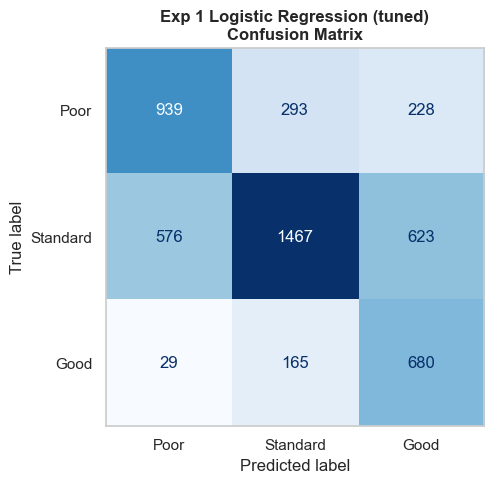

In [11]:
res_lr, trained_lr, bp_lr = tune_and_evaluate(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid={
        'C'           : [0.1],
        'class_weight': ['balanced'],
    },
    model_name="Exp 1 Logistic Regression (tuned)",
    search='grid',
)


Cross-Validation F1-Weighted per max_depth:
────────────────────────────────────────────────────
  max_depth = 3    │ F1-W = 0.6766 ± 0.0040
  max_depth = 5    │ F1-W = 0.6947 ± 0.0029
  max_depth = 7    │ F1-W = 0.6900 ± 0.0072
  max_depth = 10   │ F1-W = 0.6832 ± 0.0029
  max_depth = 15   │ F1-W = 0.6690 ± 0.0092
  max_depth = 20   │ F1-W = 0.6484 ± 0.0085
  max_depth = None │ F1-W = 0.6213 ± 0.0086

✅ Best max_depth = 5
Shape dari EDA: (20000, 21)
['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_History_Months']
  Exp 3 · Decision Tree (max_depth=5)
  Train Accuracy        : 0.7033
  Test Accuracy         : 0.6758  (OK ✅

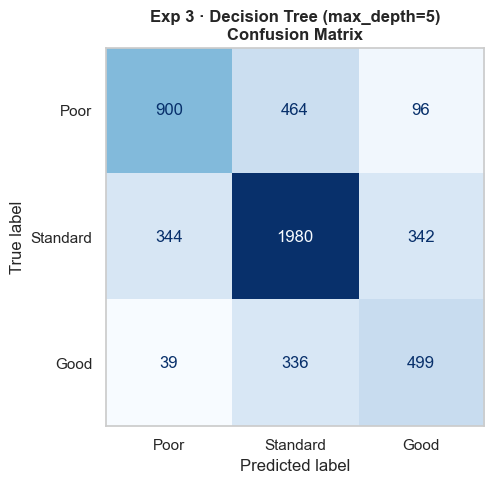

In [12]:
# Cari max_depth optimal via 5-fold cross-validation
depths      = [3, 5, 7, 10, 15, 20, None]
cv_f1_scores = []
cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross-Validation F1-Weighted per max_depth:")
print("─" * 52)
for d in depths:
    dt_cv = DecisionTreeClassifier(max_depth=d, criterion='gini', random_state=42)
    scores = cross_val_score(dt_cv, X_train_sc, y_train,
                             cv=cv, scoring='f1_weighted')
    cv_f1_scores.append(scores.mean())
    print(f"  max_depth = {str(d):4s} │ F1-W = {scores.mean():.4f} ± {scores.std():.4f}")

best_depth = depths[int(np.argmax(cv_f1_scores))]
print(f"\n✅ Best max_depth = {best_depth}")


# Train dengan best depth
dt_tuned = DecisionTreeClassifier(max_depth=best_depth, criterion='gini', random_state=42)
res_dt_tuned, trained_dt_tuned = evaluate_model(
    dt_tuned, X_train_sc, X_test_sc, y_train, y_test,
    model_name=f"Exp 3 · Decision Tree (max_depth={best_depth})"
)

# Daftarkan ke trained_models agar konsisten dgn helper tuning
trained_models[res_dt_tuned['Model']] = trained_dt_tuned


────────────────────────────────────────────────────────────
🔧 Tuning: Exp 3 · Random Forest (tuned)  (search=random, cv=5)
   Best params : {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 16}
   CV F1-macro : 0.6969
────────────────────────────────────────────────────────────
Shape dari EDA: (20000, 21)
['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_History_Months']
  Exp 3 · Random Forest (tuned)
  Train Accuracy        : 0.9036
  Test Accuracy         : 0.7072  (OVERFIT ⚠️)
  Precision (Weighted)  : 0.7087
  Recall (Weighted)     : 0.7072
  F1 Score (Weighted)  

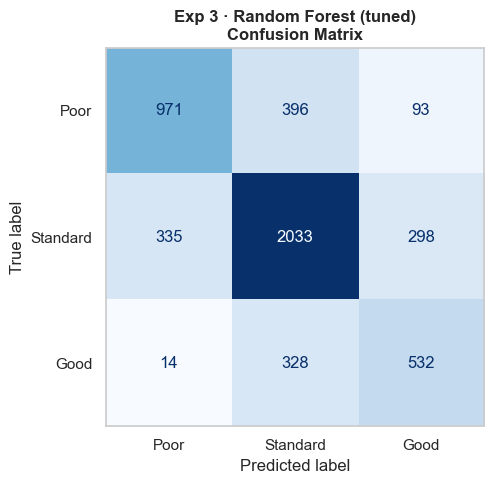

In [13]:
res_rf, trained_rf, bp_rf = tune_and_evaluate(
    RandomForestClassifier(n_jobs=-1, random_state=42),
    param_grid={
        'n_estimators'     : [300],
        'max_depth'        : [16],
        'min_samples_split': [5],
        'min_samples_leaf' : [2],
        'max_features'     : ['sqrt'],
    },
    model_name="Exp 3 · Random Forest (tuned)",
    search='random',
    n_iter=25,
)


────────────────────────────────────────────────────────────
🔧 Tuning: Exp 4 · Random Forest (Balanced, tuned)  (search=random, cv=5)
   Best params : {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 20}
   CV F1-macro : 0.6997
────────────────────────────────────────────────────────────
Shape dari EDA: (20000, 21)
['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_History_Months']
  Exp 4 · Random Forest (Balanced, tuned)
  Train Accuracy        : 0.9692
  Test Accuracy         : 0.7114  (OVERFIT ⚠️)
  Precision (Weighted)  : 0.7147
  Recall (Weighted)     : 0.7114
  F1 Score (Weighted)   : 0.7125
  F1 Score (Macro

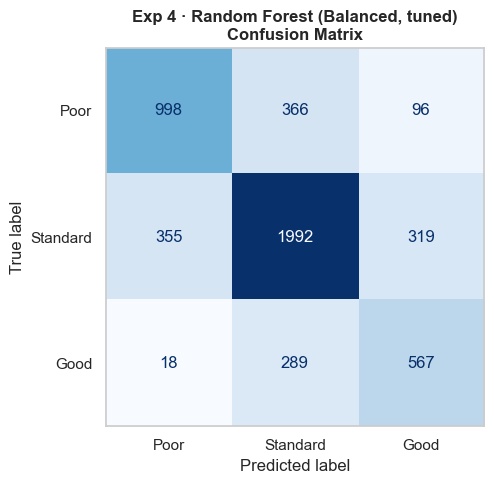

In [14]:
res_rf_bal, trained_rf_bal, bp_rf_bal = tune_and_evaluate(
    RandomForestClassifier(class_weight='balanced_subsample', n_jobs=-1, random_state=42),
    param_grid={
        'n_estimators'     : [200],
        'max_depth'        : [20],
        'min_samples_split': [2],
    },
    model_name="Exp 4 · Random Forest (Balanced, tuned)",
    search='random',
    n_iter=25,
)


────────────────────────────────────────────────────────────
🔧 Tuning: Exp 5 · Gradient Boosting (tuned)  (search=random, cv=5)
   Best params : {'subsample': 0.8, 'n_estimators': 250, 'max_depth': 3, 'learning_rate': 0.05}
   CV F1-macro : 0.6695
────────────────────────────────────────────────────────────
Shape dari EDA: (20000, 21)
['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_History_Months']
  Exp 5 · Gradient Boosting (tuned)
  Train Accuracy        : 0.7233
  Test Accuracy         : 0.6816  (OK ✅)
  Precision (Weighted)  : 0.6829
  Recall (Weighted)     : 0.6816
  F1 Score (Weighted)   : 0.6802
  F1 Score (Macro) 

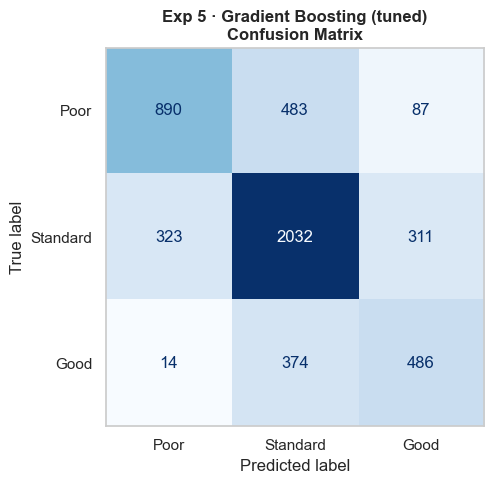

In [15]:
res_gb, trained_gb, bp_gb = tune_and_evaluate(
    GradientBoostingClassifier(
        random_state=42,
        validation_fraction=0.1,
        n_iter_no_change=10,
    ),
    param_grid={
        'n_estimators' : [250],
        'learning_rate': [0.05],
        'max_depth'    : [3],
        'subsample'    : [0.8],
    },
    model_name="Exp 5 · Gradient Boosting (tuned)",
    search='random',
    n_iter=20,
)


────────────────────────────────────────────────────────────
🔧 Tuning: Exp 6 · XGBoost (tuned)  (search=random, cv=5)
   Best params : {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.5, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
   CV F1-macro : 0.6752
────────────────────────────────────────────────────────────
Shape dari EDA: (20000, 21)
['Age', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_History_Months']
  Exp 6 · XGBoost (tuned)
  Train Accuracy        : 0.7446
  Test Accuracy         : 0.6910  (OVERFIT ⚠️)
  Precision (Weighted)  : 0.6927
  Recall (Weighted)     : 0.6910
  F1 S

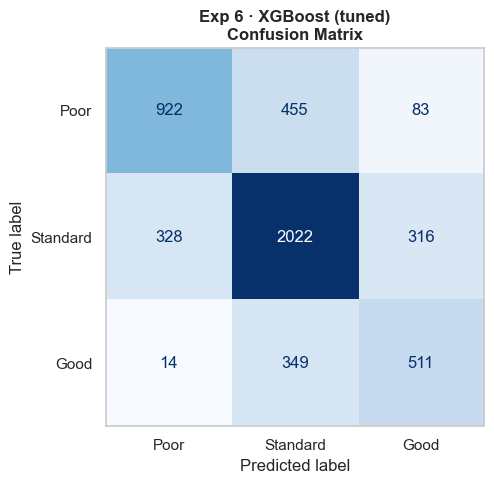

In [16]:
res_xgb, trained_xgb, bp_xgb = tune_and_evaluate(
    XGBClassifier(
        eval_metric='mlogloss', random_state=42, n_jobs=-1
    ),
    param_grid={
        'n_estimators'    : [300],
        'max_depth'       : [4],
        'learning_rate'   : [0.05],
        'subsample'       : [0.8],
        'colsample_bytree': [0.8],
        'reg_alpha'       : [0.5],
        'reg_lambda'      : [2],
    },
    model_name="Exp 6 · XGBoost (tuned)",
    search='random',
    n_iter=30,
)



Kesimpulan:
Model Terbaik : Exp 4 · Random Forest (Balanced, tuned)
F1 Weighted   : 0.7125
Test Accuracy : 0.7114



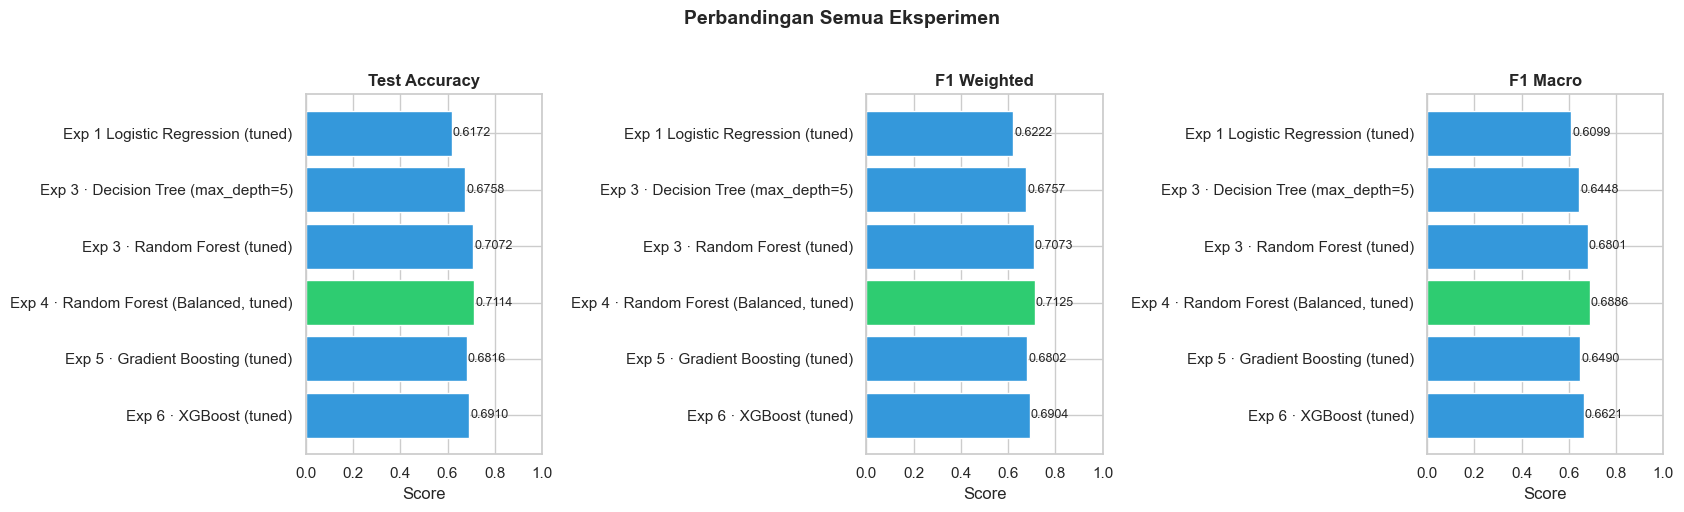

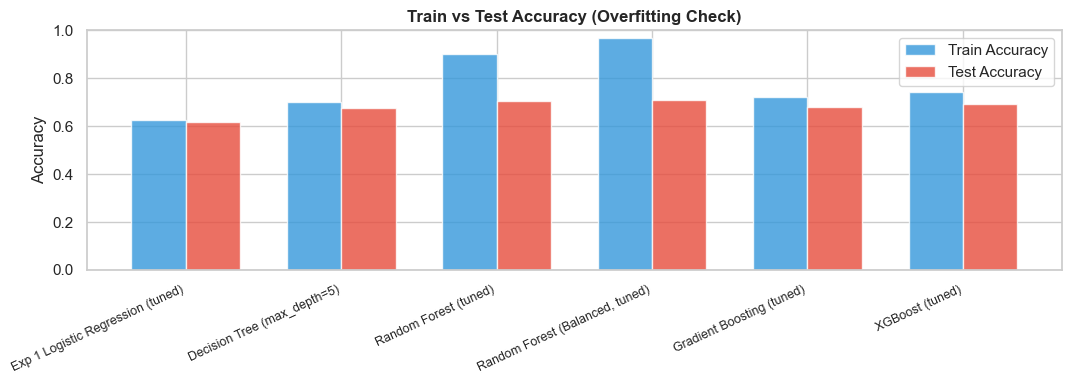

In [17]:
# ── Tambahkan baris ini untuk membuat results_df dari results_log ──
results_df = pd.DataFrame(results_log).set_index('Model')

# Baru diikuti oleh kode kesimpulan Anda yang sebelumnya:
best_name = results_df['F1 Weighted'].idxmax()
best_model_rec = results_df.loc[best_name]

print(f"""
Kesimpulan:
Model Terbaik : {best_name}
F1 Weighted   : {results_df.loc[best_name, 'F1 Weighted']:.4f}
Test Accuracy : {results_df.loc[best_name, 'Test Accuracy']:.4f}
""")
# Visualisasi Perbandingan
metrics_plot = ['Test Accuracy', 'F1 Weighted', 'F1 Macro']
fig, axes   = plt.subplots(1, 3, figsize=(17, 5))

for ax, metric in zip(axes, metrics_plot):
    vals   = results_df[metric]
    colors = ['#2ecc71' if v == vals.max() else '#3498db' for v in vals]
    bars   = ax.barh(vals.index, vals.values, color=colors, edgecolor='white')
    ax.set_xlim(0, 1)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel('Score')
    for bar, v in zip(bars, vals.values):
        ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9)
    ax.invert_yaxis()

plt.suptitle('Perbandingan Semua Eksperimen', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Overfitting Check 
fig, ax = plt.subplots(figsize=(11, 4))
x_pos   = np.arange(len(results_df))
w       = 0.35
ax.bar(x_pos - w/2, results_df['Train Accuracy'], w,
       label='Train Accuracy', color='#3498db', alpha=0.8)
ax.bar(x_pos + w/2, results_df['Test Accuracy'],  w,
       label='Test Accuracy',  color='#e74c3c', alpha=0.8)
ax.set_xticks(x_pos)
def short_label(name):
    parts = name.split('·')
    return parts[1].strip() if len(parts) > 1 else name.strip()

ax.set_xticklabels([short_label(m) for m in results_df.index],
                   rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Train vs Test Accuracy (Overfitting Check)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

Model Terbaik: Exp 4 · Random Forest (Balanced, tuned)
F1 Weighted  : 0.7125
Test Accuracy: 0.7114


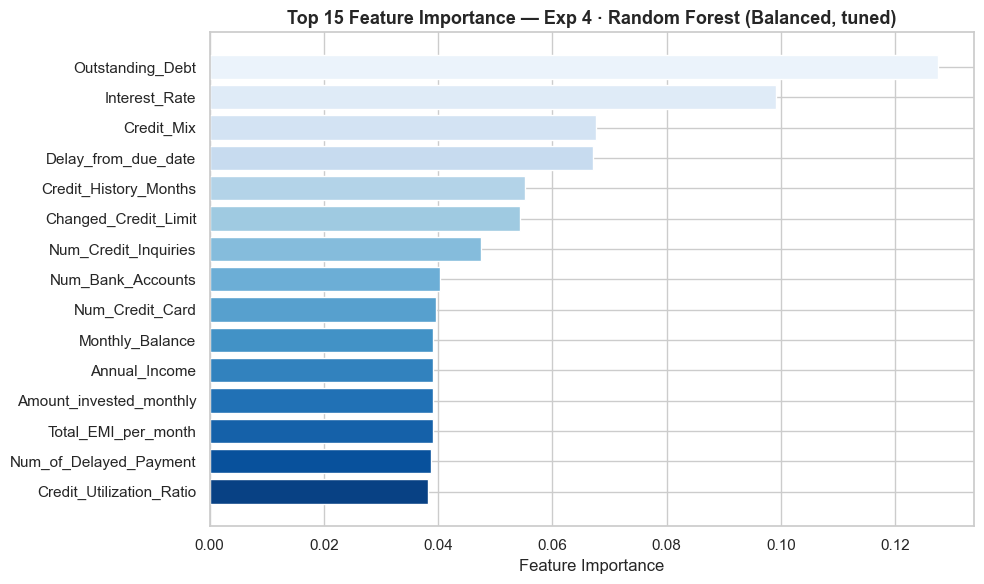

In [18]:
# Identifikasi model terbaik berdasarkan F1 Weighted
best_name = results_df['F1 Weighted'].idxmax()
print(f"Model Terbaik: {best_name}")
print(f"F1 Weighted  : {results_df.loc[best_name, 'F1 Weighted']:.4f}")
print(f"Test Accuracy: {results_df.loc[best_name, 'Test Accuracy']:.4f}")

# trained_models sudah otomatis terisi oleh tune_and_evaluate (+ Decision Tree)
best_model = trained_models[best_name]

# Feature Importance (hanya untuk model berbasis pohon)
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_imp_df = pd.DataFrame({
        'Feature'   : FEATURE_COLS,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    bars = plt.barh(feat_imp_df['Feature'][::-1],
                    feat_imp_df['Importance'][::-1],
                    color=sns.color_palette('Blues_r', len(feat_imp_df)))
    plt.xlabel('Feature Importance')
    plt.title(f'Top 15 Feature Importance — {best_name}',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    # Logistic Regression: koefisien
    coef_df = pd.DataFrame(
        np.abs(best_model.coef_).mean(axis=0),
        index=FEATURE_COLS, columns=['Mean |Coef|']
    ).sort_values('Mean |Coef|', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(coef_df.index[::-1], coef_df['Mean |Coef|'][::-1],
             color=sns.color_palette('Blues_r', len(coef_df)))
    plt.xlabel('Mean |Coefficient|')
    plt.title(f'Top 15 Fitur — {best_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
